In [8]:
import mne
import numpy as np
import os
import json

from functions import ephy_plotting, utils, analysis, ephy_meta_function

# 1. Load pre-processed EEG epochs

In [3]:
working_path = os.path.dirname(os.getcwd())
results_path = os.path.join(working_path, "results")
behav_results_saving_path = os.path.join(results_path, "behav_results")
# read the json file containing the included and excluded subjects, based on the behavioral results
included_excluded_file = os.path.join(behav_results_saving_path, 'final_included_subjects.json')
with open(included_excluded_file, 'r') as file:
    included_subjects = json.load(file)
print(f'Included_subjects: {included_subjects}')

Included_subjects: ['C003 mSST', 'C004 mSST', 'C006 mSST', 'C007 mSST', 'C008 mSST', 'C009 mSST', 'C010 mSST', 'C011 mSST', 'C012 mSST', 'C013 mSST', 'C014 mSST', 'C015 mSST', 'sub006 DBS ON mSST', 'sub006 DBS OFF mSST', 'sub011 DBS OFF mSST', 'sub011 DBS ON mSST', 'sub012 DBS ON mSST', 'sub012 DBS OFF mSST', 'sub015 DBS OFF mSST', 'sub015 DBS ON mSST', 'sub019 DBS ON mSST', 'sub019 DBS OFF mSST', 'sub023 DBS OFF mSST', 'sub023 DBS ON mSST', 'sub025 DBS ON mSST', 'sub025 DBS OFF mSST', 'sub027 DBS ON mSST', 'sub027 DBS OFF mSST', 'sub028 DBS OFF mSST', 'sub028 DBS ON mSST', 'sub029 DBS ON mSST', 'sub029 DBS OFF mSST', 'sub032 DBS ON mSST', 'sub032 DBS OFF mSST', 'sub033 DBS ON mSST', 'sub033 DBS OFF mSST']


In [13]:
epochs_path = "D:\\Juliette\\data mSST\\eeg_epochs"

sub_dict_epochs = {}  #  Stores the epochs for each subject/session

for session_ID in included_subjects:
    # check if sub folder exists (some subjects have no clean EEG data)
    if not os.path.exists(os.path.join(epochs_path, session_ID.split(' ')[0])):
        print(f"Epochs folder for {session_ID} does not exist. Maybe subject has no clean EEG data. Skipping this session.")
        continue    
    if session_ID.startswith('sub'):
        epochs = mne.read_epochs(
            os.path.join(epochs_path, 
            session_ID.split(' ')[0],
            ('DBS ' + session_ID.split(' ')[2]),
            f"{session_ID}_EEG_cleaned-long-epo.fif"
            ), 
            preload=True)
        
    elif session_ID.startswith('C'):
        epochs = mne.read_epochs(
            os.path.join(epochs_path, 
            session_ID.split(' ')[0],
            f"{session_ID}_EEG_cleaned-long-epo.fif"
            ), 
            preload=True)
    
    epochs.resample(250, npad='auto')   # downsample to 250Hz to save computation time and memory
    sub_dict_epochs[session_ID] = epochs

Reading D:\Juliette\data mSST\eeg_epochs\C004\C004 mSST_EEG_cleaned-long-epo.fif ...
    Found the data of interest:
        t =   -3500.10 ...    3500.10 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
407 matching events found
No baseline correction applied
0 projection items activated
Reading D:\Juliette\data mSST\eeg_epochs\C006\C006 mSST_EEG_cleaned-long-epo.fif ...
    Found the data of interest:
        t =   -3500.03 ...    3500.03 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
390 matching events found
No baseline correction applied
0 projection items activated
Reading D:\Juliette\data mSST\eeg_epochs\C007\C007 mSST_EEG_cleaned-long-epo.fif ...
    Found the data of interest:
        t =   -3500.03 ...    3500.03 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
319 matching events found
No baseline correction applied
0 projection items activated
Reading D:\Juliette\data mSST\eeg_

In [14]:
# print summary of the epochs for each subject/session
for session_ID, epochs in sub_dict_epochs.items():
    print(f"Subject/Session: {session_ID}")
    print(epochs)

Subject/Session: C004 mSST
<EpochsFIF | 407 events (all good), -3.5 – 3.496 s (baseline off), ~173.9 MB, data loaded, with metadata,
 'GC': 54
 'GF': 51
 'GO': 158
 'GS': 45
 'continue': 55
 'stop': 44>
Subject/Session: C006 mSST
<EpochsFIF | 390 events (all good), -3.5 – 3.496 s (baseline off), ~166.7 MB, data loaded, with metadata,
 'GC': 53
 'GF': 52
 'GO': 145
 'GS': 43
 'continue': 54
 'stop': 43>
Subject/Session: C007 mSST
<EpochsFIF | 319 events (all good), -3.5 – 3.496 s (baseline off), ~136.3 MB, data loaded, with metadata,
 'GC': 38
 'GF': 42
 'GO': 127
 'GS': 39
 'continue': 36
 'stop': 37>
Subject/Session: C008 mSST
<EpochsFIF | 369 events (all good), -3.5 – 3.496 s (baseline off), ~157.7 MB, data loaded, with metadata,
 'GC': 51
 'GF': 45
 'GO': 156
 'GS': 34
 'continue': 49
 'stop': 34>
Subject/Session: C009 mSST
<EpochsFIF | 381 events (all good), -3.5 – 3.496 s (baseline off), ~162.8 MB, data loaded, with metadata,
 'GC': 46
 'GF': 52
 'GO': 145
 'GS': 45
 'continue': 4

# 2. Plot average TFR of GO trials for all subjects/sessions

In [15]:
# plot average TFR for successful GO trials for each subject/session to assess data quality

######################
### TFR PARAMETERS ###
######################

decim = 1 
fmin_freq = 1
#freqs = np.arange(fmin_freq, fmax, 1) 
freqs = np.arange(fmin_freq, 80, 1)
# For 500ms time resolution at 1 Hz: n_cycles = 1 * 0.5 = 0.5
# For 50ms time resolution at 40 Hz: n_cycles = 40 * 0.05 = 2
# Linear interpolation between these points
#n_cycles = 0.5 + (freqs - 1) * (2 - 0.5) / (40 - 1)
#n_cycles = freqs / 2.0
n_cycles = np.minimum(np.maximum(freqs / 2.0, 2), 20)

tfr_args = dict(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=decim,
    return_itc=False,
    average=False
)        

baseline_correction_method = 'group_average' # 'group_average' or 'single_trial'
tmin_tmax = [0, 1500]
vmin_vmax = [-5, 5] if baseline_correction_method == 'single_trial' else [-70, 70]

In [17]:
ROIs = {
    'preSMA': ['Fz', 'Cz' #'FC1', 'FC2', ', 'FC5', 'FC6'
               ],
    'r_IFG': ['F8', 'FC6', 'F4'],
    'l_IFG': ['F7', 'FC5', 'F3'],
    'l_M1': ['C3', 'FC5', 'CP1'],
    'r_M1': ['C4', 'FC6', 'CP2'],
    'r_DLPFC': ['F4', 'FC2'],
    'l_DLPFC': ['F3', 'FC1'],
    'occipital': ['O1', 'O2', 'Oz'],
    'central': ['Cz'],
    'C3': ['C3'],
    'C4': ['C4']
}

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.9s finished
[Parallel(n_jobs=1)]

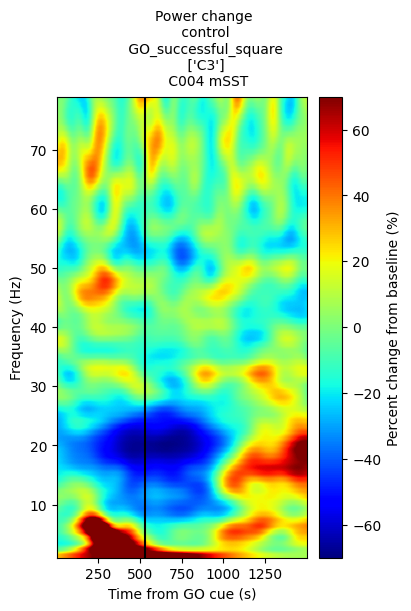

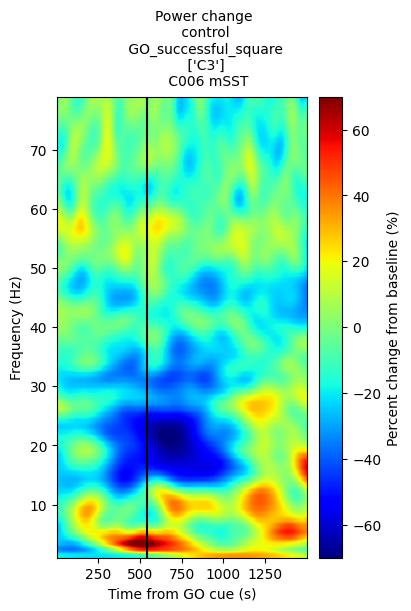

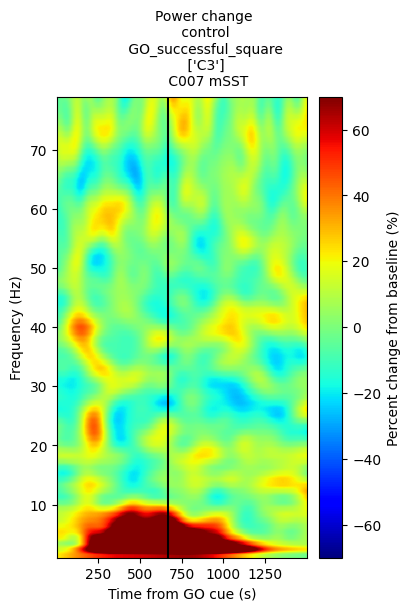

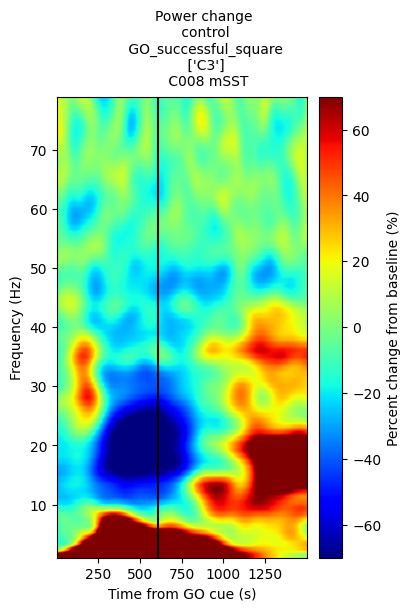

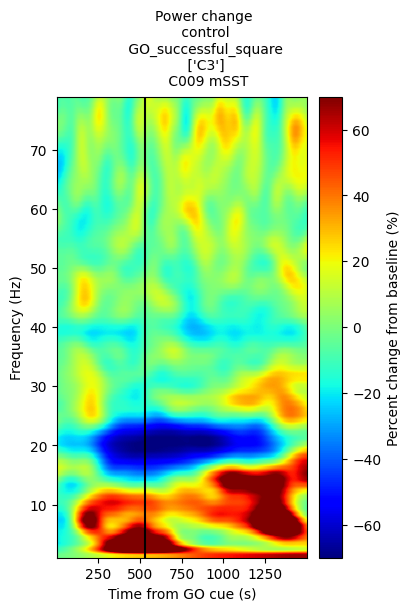

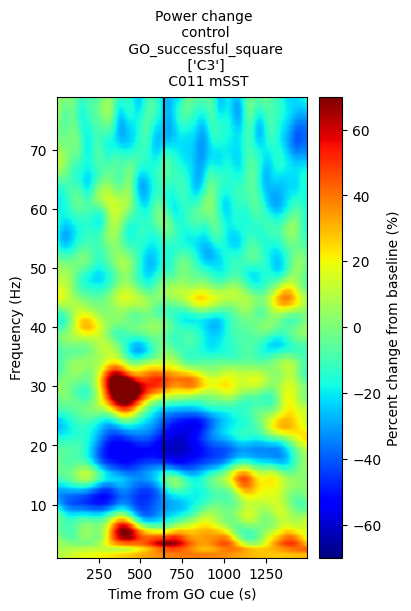

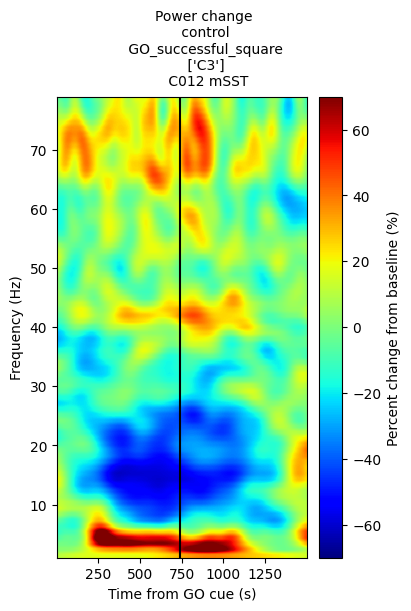

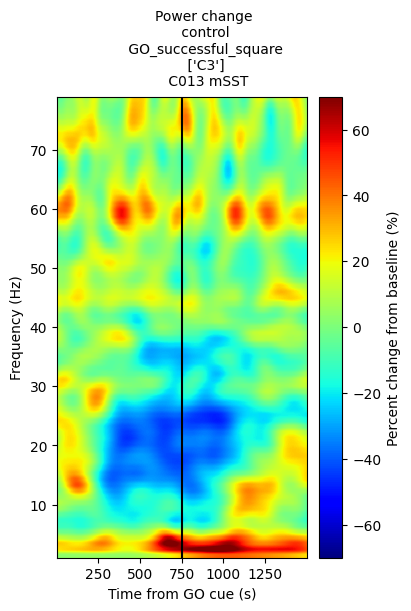

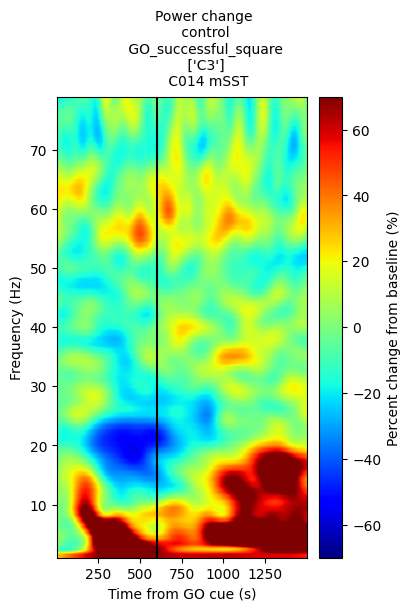

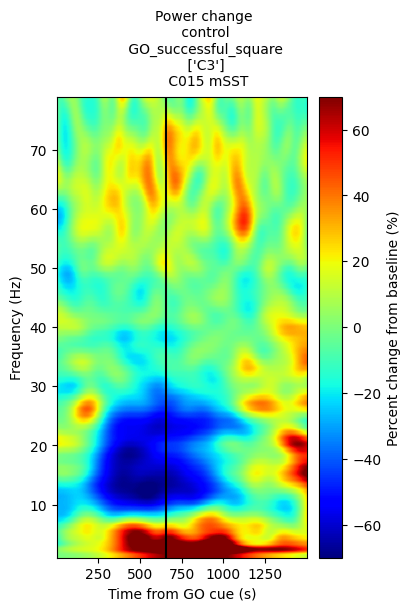

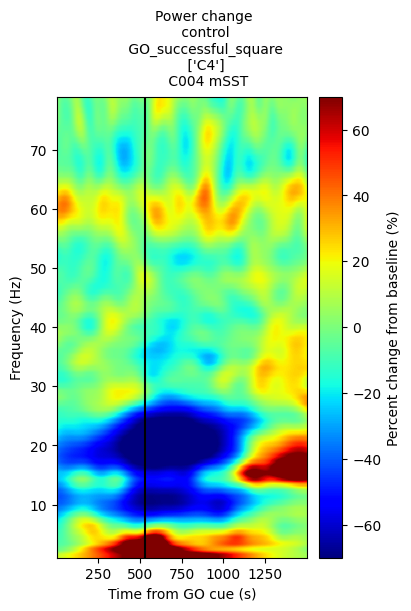

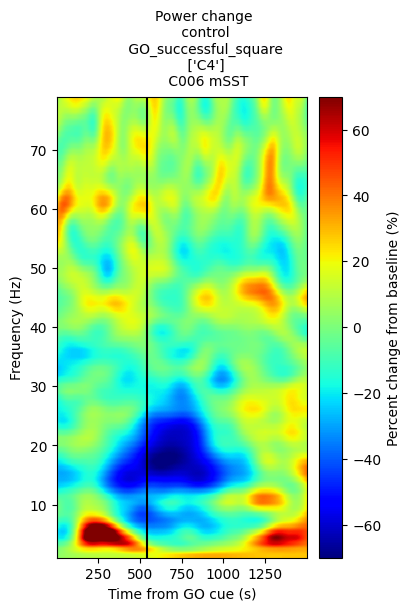

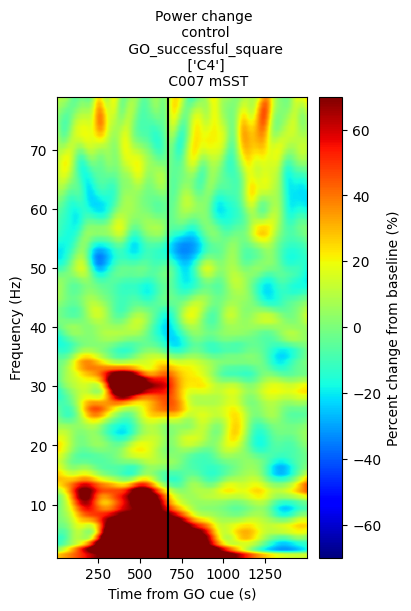

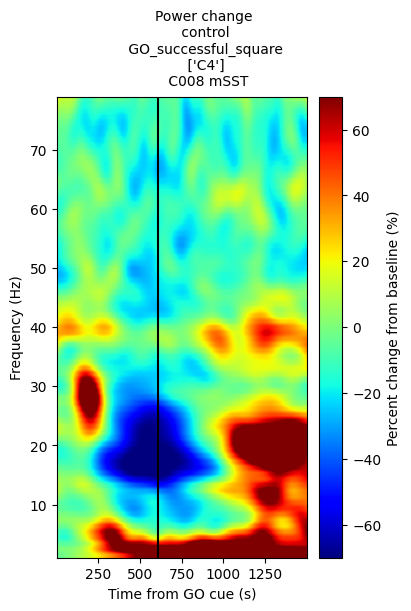

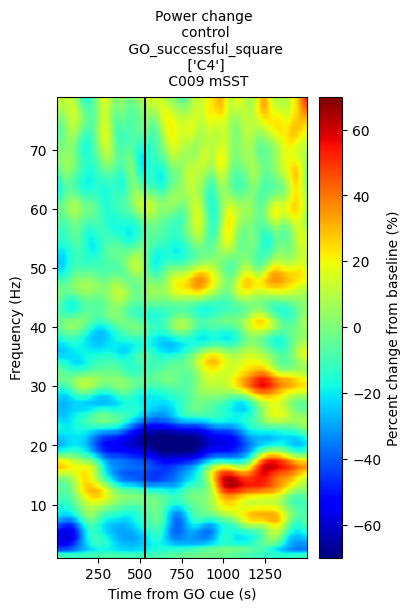

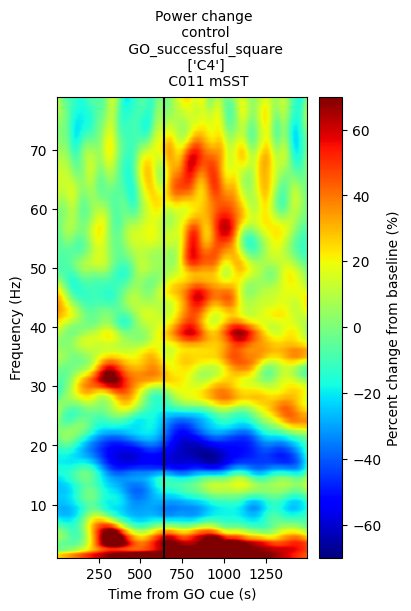

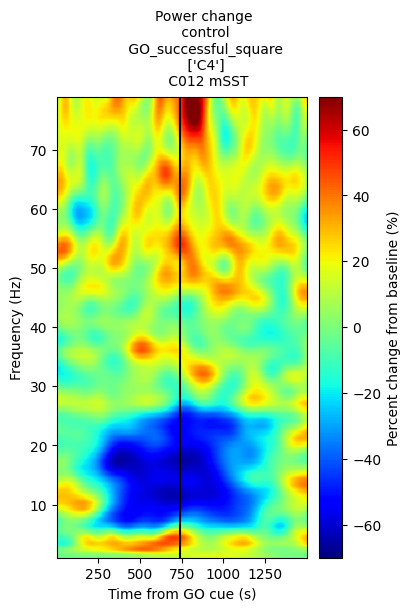

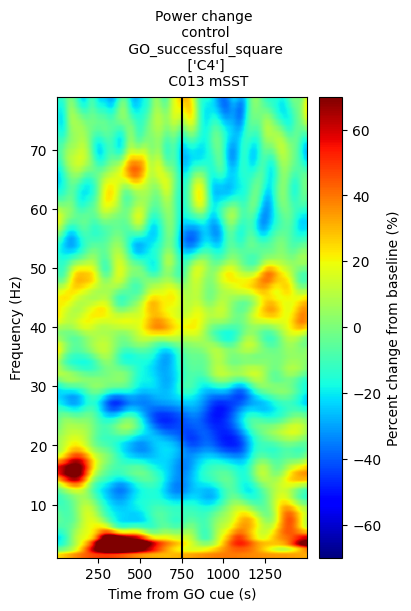

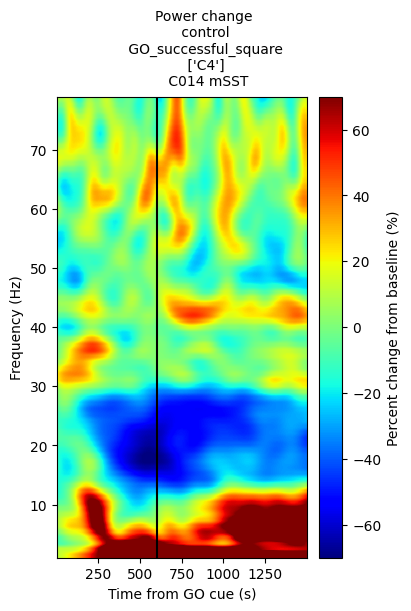

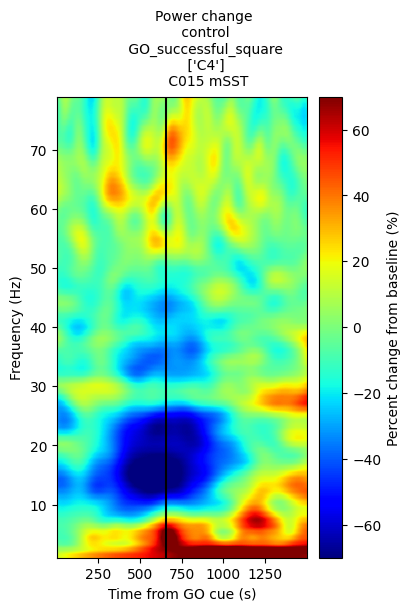

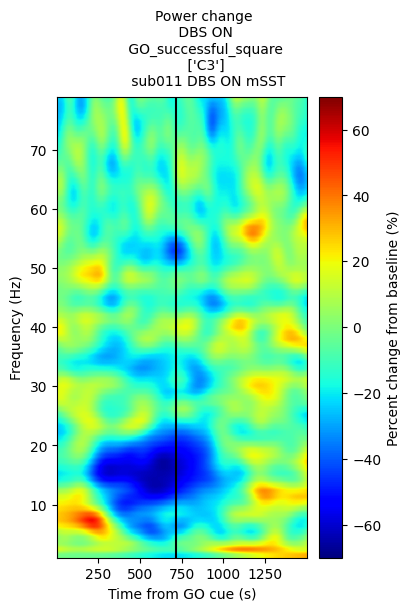

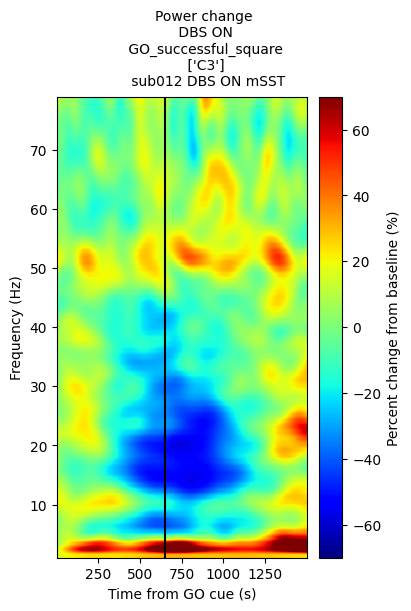

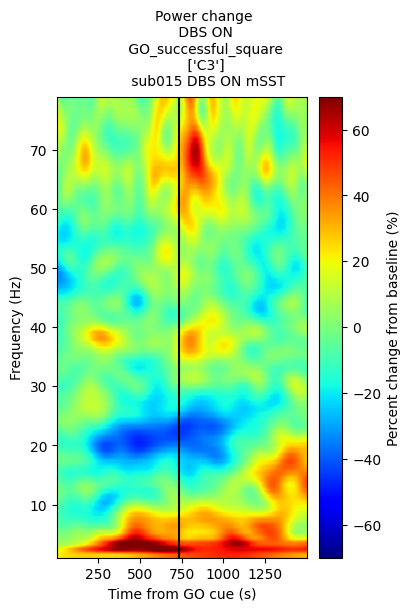

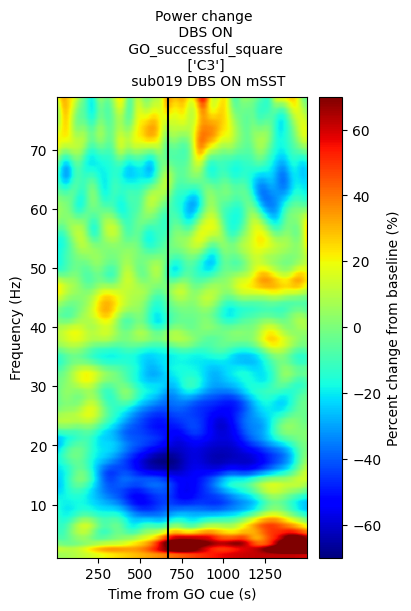

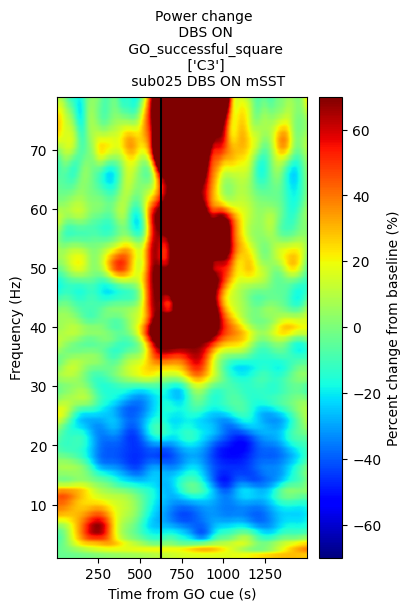

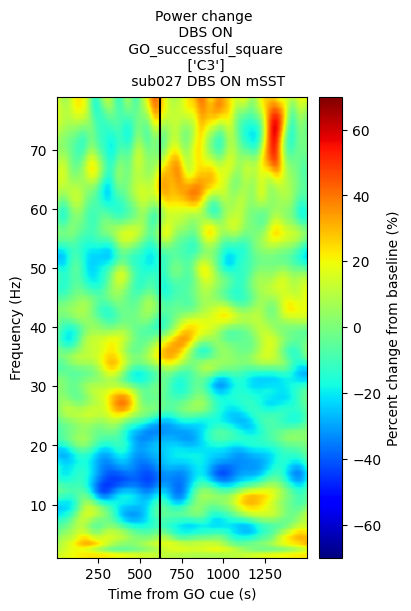

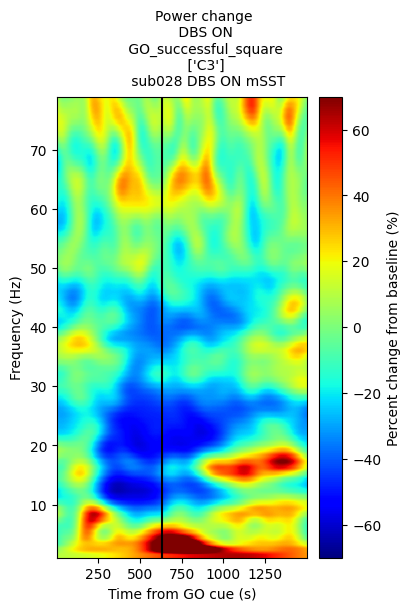

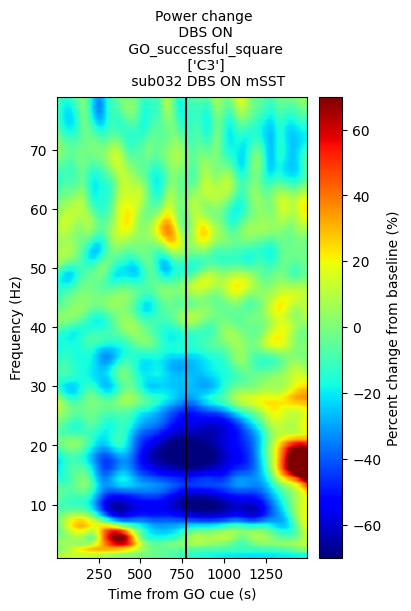

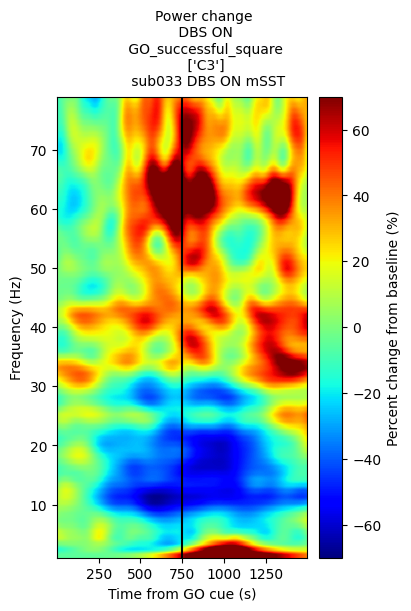

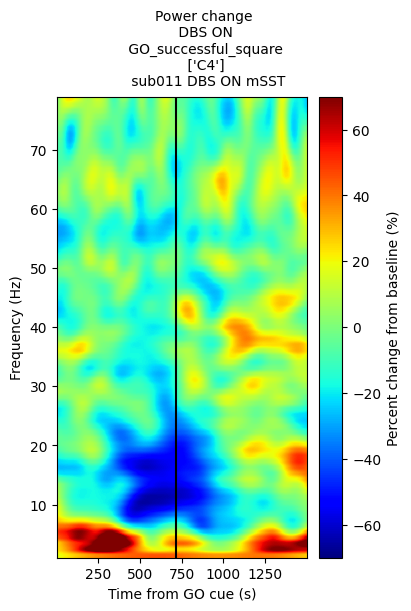

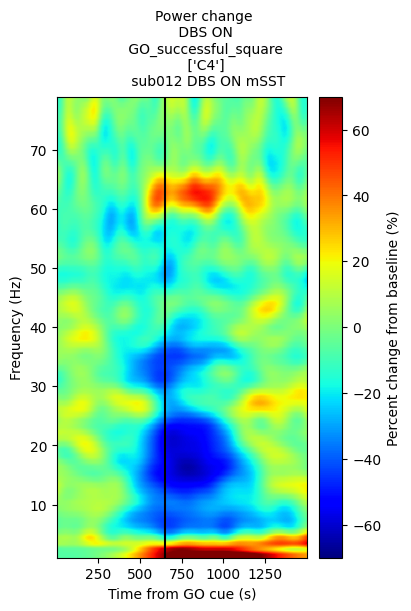

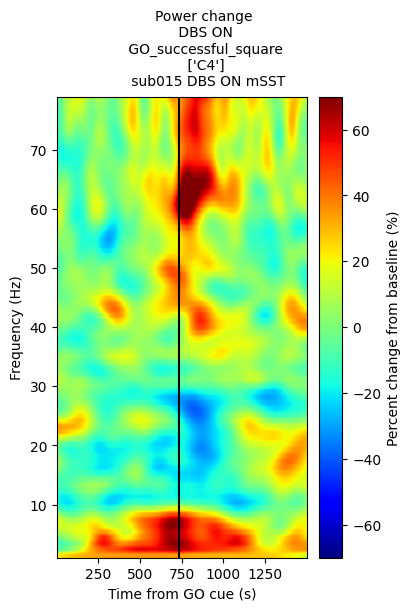

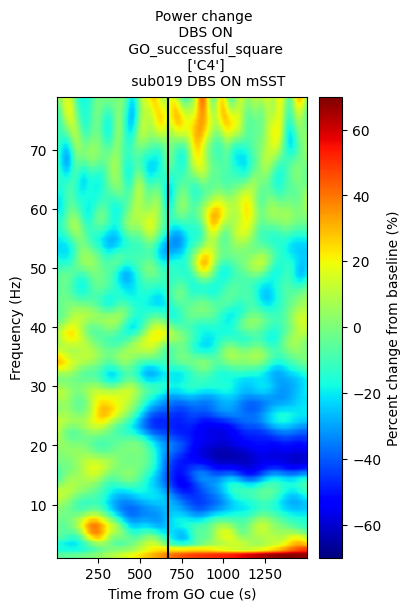

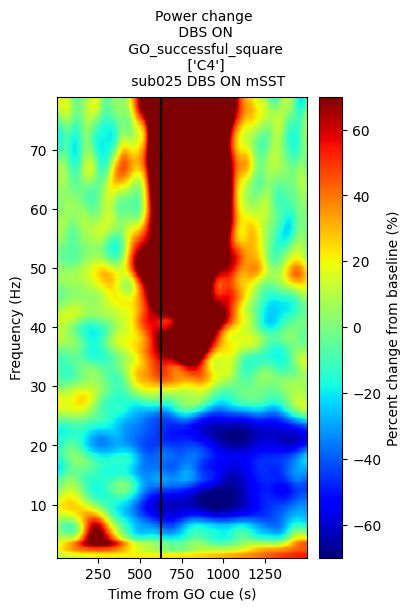

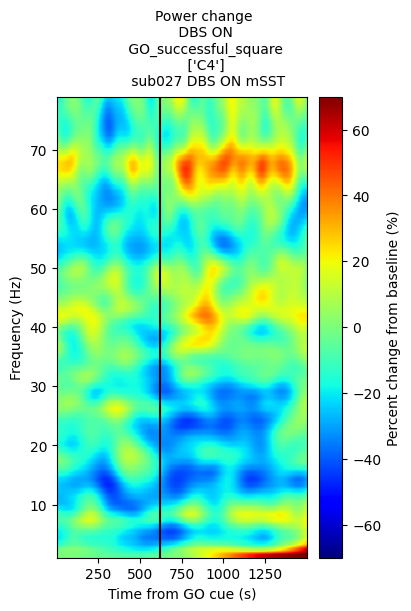

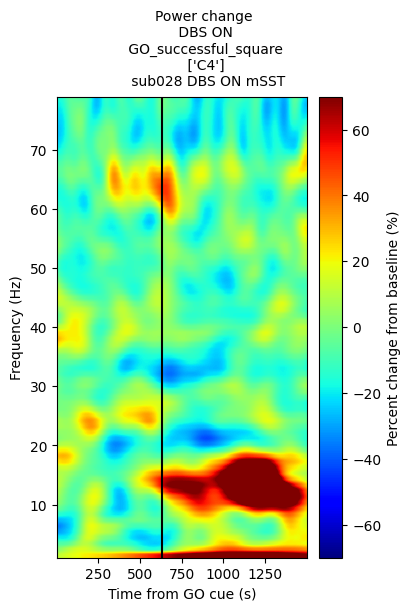

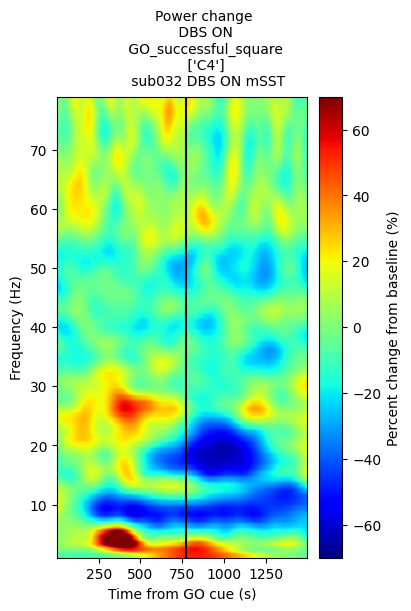

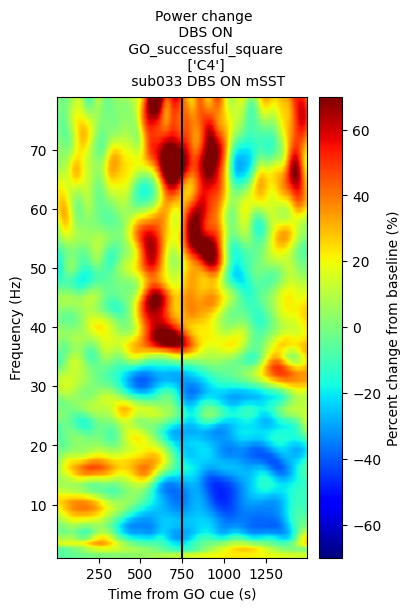

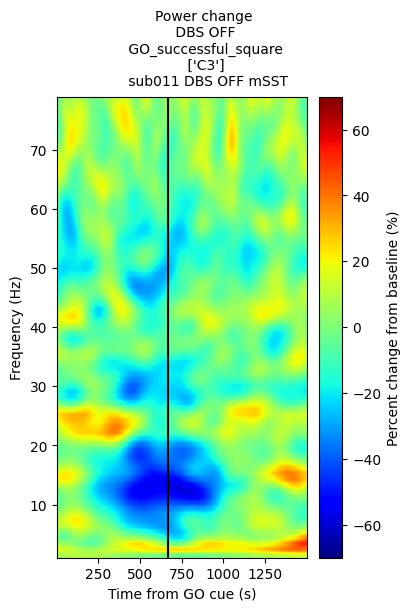

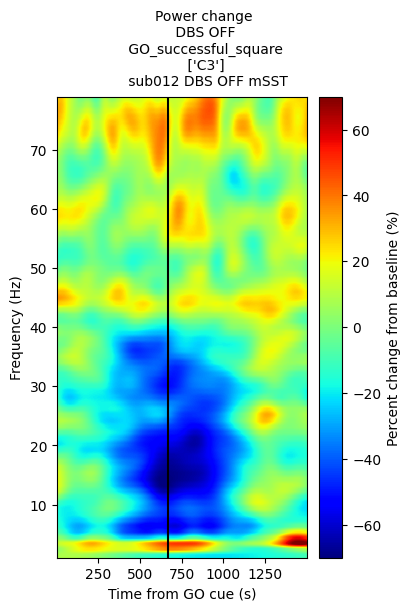

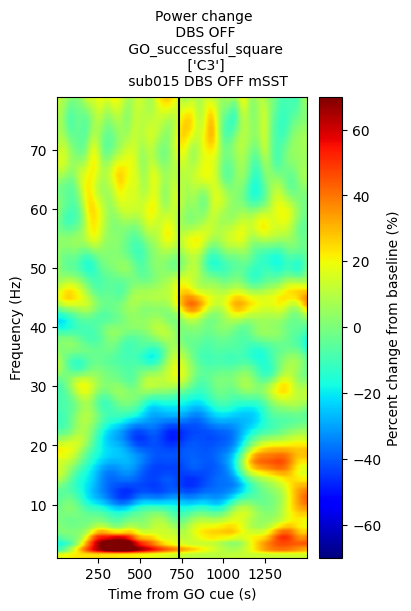

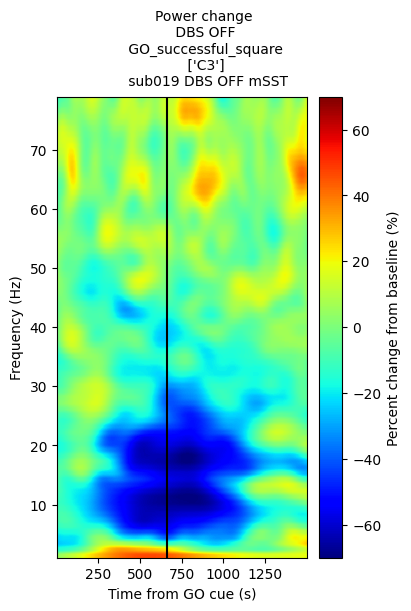

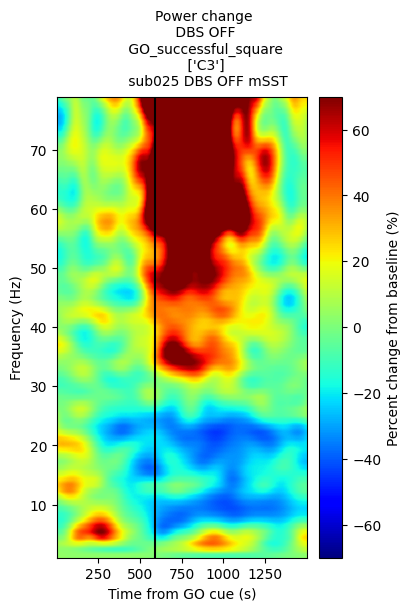

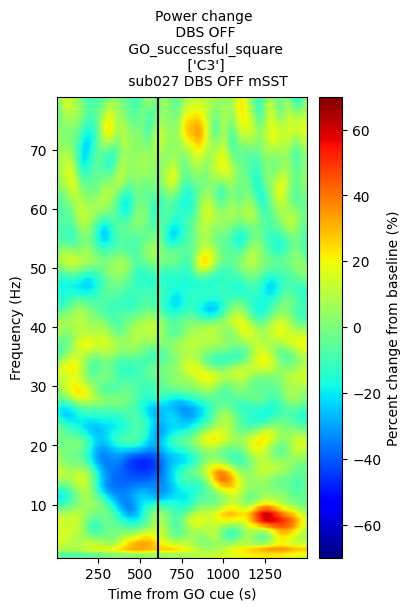

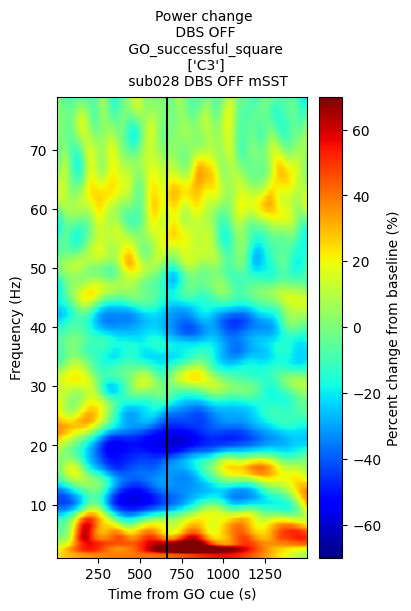

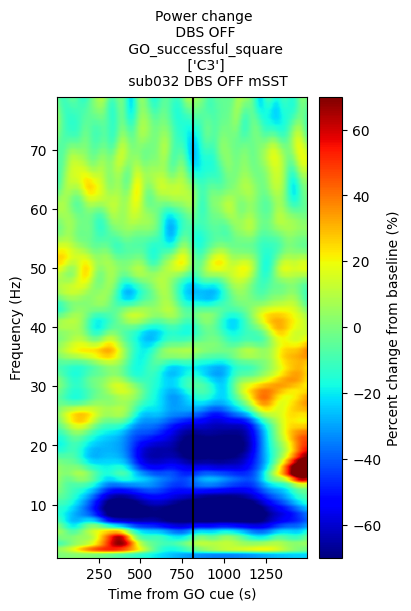

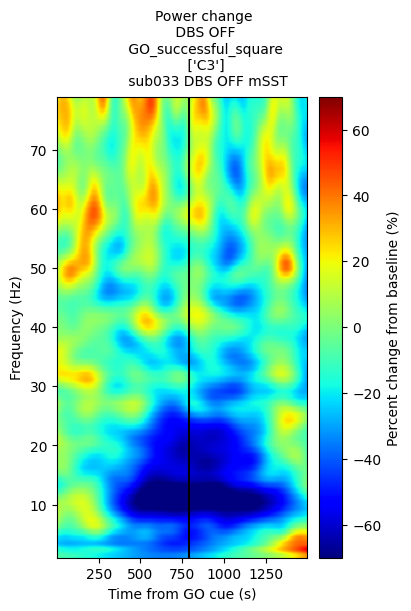

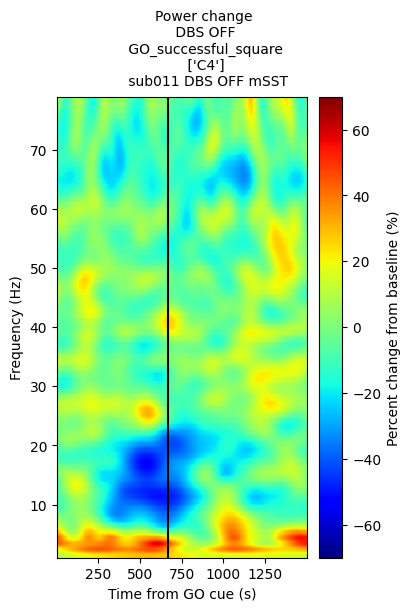

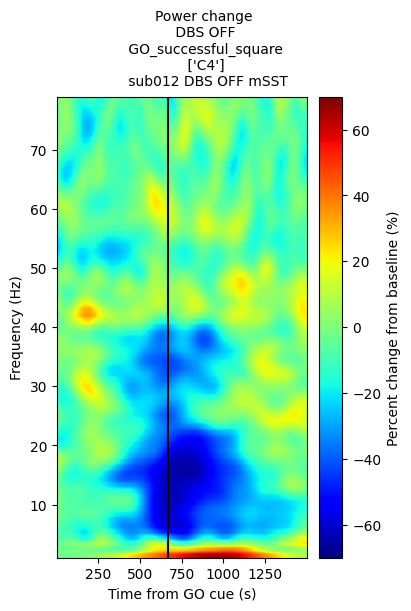

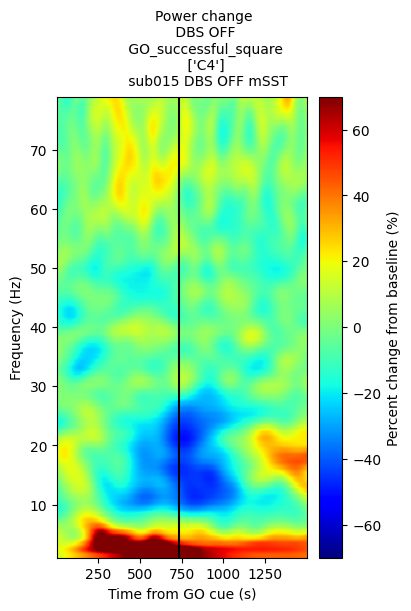

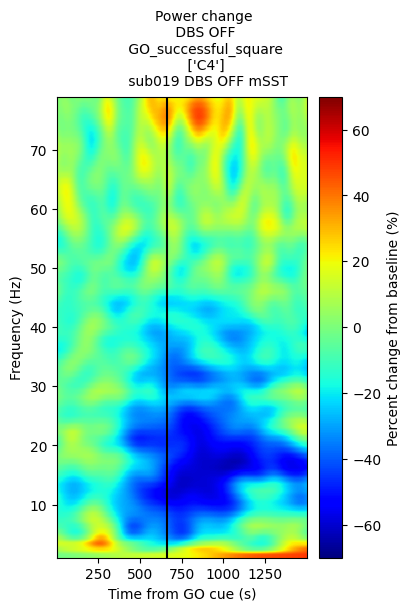

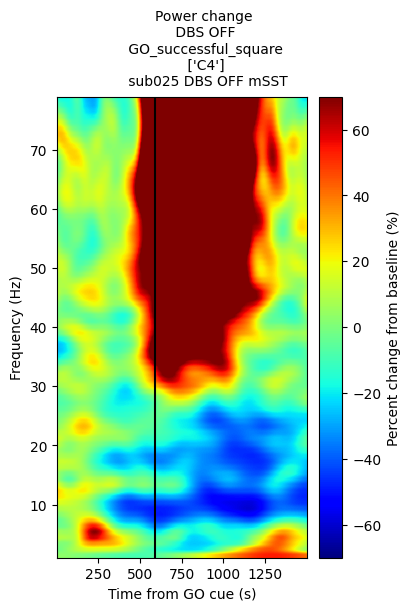

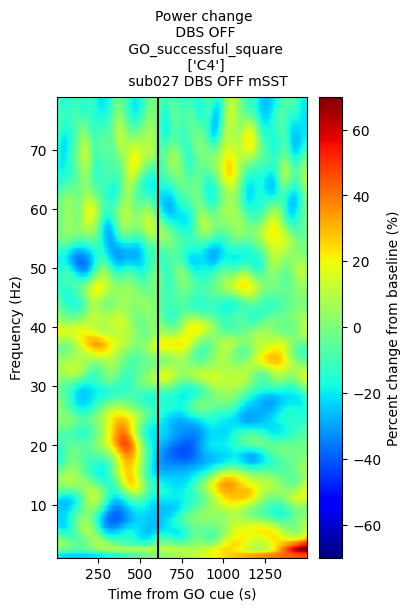

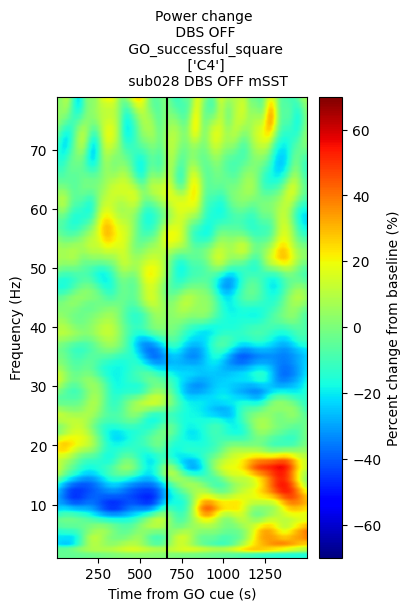

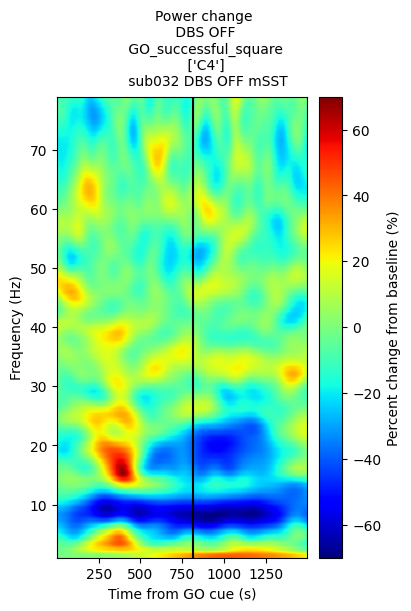

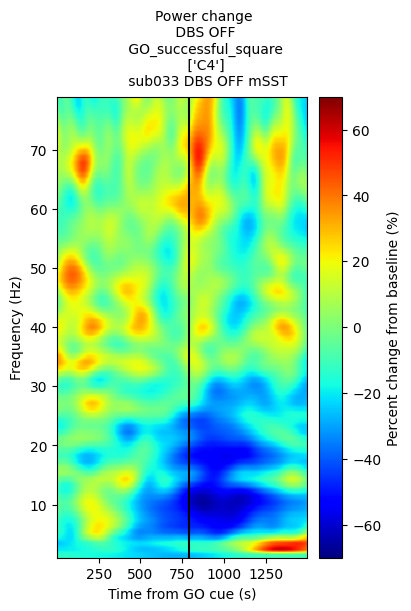

In [18]:
for epoch_conds in [['GO_successful_square']]:
# for epoch_conds in [['GF_successful_square'], ['GC_successful_square'], ['GS_successful_square'],['GS_unsuccessful_square'], ['GC_successful_triangle'], ['GS_successful_triangle']]:
    temp_save = os.path.join(results_path, 'eeg_epochs', 'figures', 'TFR', epoch_conds[0])
    if not os.path.exists(temp_save):
        os.makedirs(temp_save)

    tfr_dict = {
        'DBS OFF': {},
        'DBS ON': {},
        'control': {}
    }
    for condition in ['control', 'DBS ON', 'DBS OFF']:
        for roi in [ROIs['C3'], ROIs['C4']]:
            ephy_meta_function.meta_function_tfr_intra_group(
                    tfr_dict = tfr_dict, # store tfr results
                    sub_group = condition, # specify which group to analyze (e.g. 'DBS OFF', 'DBS ON', 'controls')
                    sub_dict_epochs = sub_dict_epochs, # dictionary containing all subjects' data
                    single_sub = True, # True or False, whether to plot single subject TFRs or group averages
                    epochs_cond = epoch_conds, # what condition(s) to analyse (e.g. ['GO_successful_square'], ['GO_successful_square', 'GS_successful_square'])
                    roi = roi, # region of interest (e.g. ['Left_STN'], ['Right_STN'], ['Left_STN', 'Right_STN']). A list creates an average of all channels in the list.
                    tfr_args = tfr_args, # dictionary containing tfr parameters (e.g. frequencies of interest, number of cycles, etc.)
                    tmin_tmax = [0, 1.5], # time window of interest for plotting (e.g. [-0.5, 1.5])
                    plot_contrast = False, # True or False, whether to plot contrasts between two conditions
                    plot_single_condition = True, # True or False, whether to plot single conditions
                    vmin_vmax = [-70, 70], # min and max values for color scale (e.g. [-70, 70] if in percentage change)
                    baseline_correction = True, # True or False, whether to apply baseline correction
                    baseline_correction_method = 'group_average', # method for baseline correction (e.g. 'group_average' or 'single_trial')
                    saving_path = temp_save, # path to save the figures
                    save_as = 'png', # format to save the figures (e.g. 'png', 'pdf')
                    threshold_gc_dict = None # dictionary containing the GC threshold for each subject (only needed if using slowGC or fastGC conditions
            )   